# 07 · Weights: handbook equations, calibration on the XV-15, the tiltrotor wing, and closure

In conceptual sizing, weight is where most of the uncertainty lives. This tutorial shows where every kilogram of the
Halo comes from, how the handbook equations are calibrated on one real aircraft, how the wing is sized for stiffness
rather than strength, how closure works, and how honest the empty-weight number is.

**What you will learn**
1. How the mass breakdown is assembled, and the one object through which take-off mass feeds every correlation.
2. Raymer and AFDD weight equations, and the XV-15 calibration factors (including the uncomfortable ones).
3. The NDARC/AFDD tiltrotor wing: sized by whirl-flutter frequency placement and a jump take-off; its validation.
4. Mass closure, the Lagrange multiplier as a growth factor, and the hover-trim CG constraint.
5. Growth allowance versus uncertainty: the empty-weight prediction and its chance of meeting a target.

**Run time:** under a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import fields, replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft
from aircraft_closure.vehicle.condition import StructuralDesignCondition

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)

## 1. Assembling the mass

`Aircraft` (`vehicle/aircraft.py`) holds physical objects (wing, tails, fuselage, gear, systems, nacelles, payload,
fuel, equipment, and the powertrain installation), each owning its geometry and its mass method. The mass of every
weight-dependent group needs the design gross weight, the load factor and the dynamic pressure; they all come from
one object, the **`StructuralDesignCondition`**, which the sizing builds from the take-off mass *variable* and the
*solved* cruise speed and L/D. That single object is the whole of the weight "snowball" coupling.

In [2]:
cruise = next(s for s in ref.segments if s["label"] == "cruise")
condition = StructuralDesignCondition(mass_design_kg=ref.mass_takeoff_kg, load_factor_ultimate=assumptions.load_factor_ultimate,
                                      velocity_cruise_m_s=cruise["velocity_m_s"], altitude_cruise_m=cruise["altitude_start_m"],
                                      lift_to_drag_cruise=ref.lift_to_drag_cruise)
breakdown = aircraft.get_mass_breakdown(condition)
total = breakdown.total()
print(f"{'group':<18}{'kg':>9}{'x_cg m':>9}")
for f in fields(breakdown):
    item = getattr(breakdown, f.name)
    if item.mass > 0:
        print(f"{f.name:<18}{item.mass:9.1f}{item.x_cg:9.2f}")
print(f"{'total':<18}{total.mass:9.1f}{total.x_cg:9.2f}")
check("rebuilding the sized aircraft reproduces its take-off mass (closure)", abs(total.mass - ref.mass_takeoff_kg) < 1e-3)

group                    kg   x_cg m
wing                  407.9     5.40
horizontal_tail        47.0    10.31
vertical_tail          35.8    10.24
fuselage              560.2     4.95
landing_gear          258.4     5.12
systems               407.3     3.00
powertrain           2870.9     5.32
payload               900.0     5.11
fuel                  936.4     5.11
nacelles              194.8     6.29
equipment             266.3     3.50
total                6885.1     5.11
PASS  rebuilding the sized aircraft reproduces its take-off mass (closure)


The CG aggregation is AeroSandbox's `MassProperties` addition (not re-implemented). Note that the code's
"empty mass" (`mass_empty_kg`) is take-off mass minus payload and fuel: it **includes the battery** and every
powertrain item.

## 2. Handbook equations and the XV-15 calibration

| Group | Equation | Source |
|---|---|---|
| wing (old), tails, fuselage, landing gear, flight controls | Raymer general-aviation weights (via AeroSandbox) | Raymer, 15.3.3 |
| rotor blades and hubs | AFDD82: f(blades, radius, chord, tip speed, flap frequency ν) | NDARC ch. 19 |
| gearboxes and rotor shaft | AFDD00 / AFDD83: ∝ power^0.78 / rotor rpm^0.81 (torque at the rotor) | NDARC ch. 19 |
| engine support, air induction, cowling | AFDD82 | NDARC ch. 19 |
| tiltrotor wing | NDARC 19-1.1 (section 3) | NDARC |
| turboshaft | AeroSandbox mass-power regression | AeroSandbox |

Each group is multiplied by a **calibration factor**: the ratio of the XV-15's published group weight (TM X-62407,
Nov 1974 weight statement) to the equation's prediction for the XV-15. The XV-15 is the only tiltrotor with a public
group weight statement at this level.

In [3]:
from examples.xv15_reference import Xv15MassFactors, calibration_factors, solve_xv15_closure
factors = calibration_factors()
for f in fields(factors):
    print(f"   {f.name:<16}{getattr(factors, f.name):6.3f}")
uncal, cal = solve_xv15_closure(factors=Xv15MassFactors()), solve_xv15_closure(factors=factors)
print(f"XV-15 closure, uncalibrated: {lb(uncal.mass_takeoff_kg):,.0f} lb take-off (actual 13,000 lb)")
print(f"XV-15 closure, calibrated  : {lb(cal.mass_takeoff_kg):,.0f} lb take-off")
check("uncalibrated XV-15 closes at about 11,315 lb (13 % light)", abs(lb(uncal.mass_takeoff_kg) - 11315) < 10)
check("calibrated XV-15 closes at 13,000 lb", abs(lb(cal.mass_takeoff_kg) - 13000) < 1)

   rotor            0.693
   wing             1.930
   tail             1.126
   fuselage         2.071
   alighting_gear   0.869
   flight_controls  3.786
   powerplant       1.145
   transmission     0.999
   wing_tiltrotor   1.327


XV-15 closure, uncalibrated: 11,315 lb take-off (actual 13,000 lb)
XV-15 closure, calibrated  : 13,000 lb take-off
PASS  uncalibrated XV-15 closes at about 11,315 lb (13 % light)
PASS  calibrated XV-15 closes at 13,000 lb


What the factors say:

- **Drive system 1.00, powerplant 1.14, tails 1.13, gear 0.87:** the equations work on this aircraft.
- **Fuselage 2.07:** the XV-15 fuselage is a crewed, crashworthy research cabin. The Halo uses **1.70** instead,
  anchored to a drawn structural layout of an uncrewed, unpressurized cargo fuselage (plan 037, about 1.73 × raw
  Raymer); that one change cut the design from 14,037 to 13,307 lb at the time.
- **Raymer wing 1.93:** a general-aviation strength regression misses a tiltrotor wing, which is sized by stiffness.
  Hence the dedicated tiltrotor wing model (section 3, its own factor 1.33).
- **Rotor 0.69:** the AFDD rotor equation goes as ν^2.53 in the flap frequency, and the XV-15's 1.55/rev was read
  off a plot; ν = 1.35 would match without a factor. One digitized number moves the rotor group by 50 %.
- **Flight controls 3.79:** the weakest group. The XV-15's "hydraulics and flight controls" includes redundant
  research systems and the rotor and conversion controls a GA equation does not know about. The Halo keeps the
  factor (conservative).

**The honest caveat:** calibration factors reproduce the XV-15 *by construction*, so the XV-15 is not a validation.
The validations are the predictions made without refitting: the tiltrotor wing on two other aircraft (next
section), the JVX rotor (tutorial 03), the XV-15 hover and hot-day power (tutorial 04's lapse fit predicts the 95 °F
hover weights within −2.6 %).

## 3. The tiltrotor wing: sized by stiffness

A tiltrotor wing carries a heavy rotor and nacelle at each tip and must keep its **torsion and beam frequencies
above the rotor's once-per-rev** in airplane mode (or the rotor-pylon-wing system can go into **whirl flutter**). It
is then checked for strength in a **2 g jump take-off** (rotor thrust at the tips). NDARC 19-1.1 (after Chappell &
Peyran) sizes it in one explicit pass:

1. torque box from the **torsion frequency**: GJ = ω_T² I_pylon (thin closed tube);
2. spar caps for the chord and **beam frequencies** where the box is not stiff enough;
3. extra caps for the **jump take-off** bending moment;
4. fairings, control surfaces, fittings by area or fraction.

The required frequencies are the XV-15's (torsion 1.09, beam 0.43, chord 0.83 per rev) **per rev of a design rotor
speed, which is itself a design variable**; every airplane-mode point of the mission must then keep its own rotor
speed low enough that the realized frequencies stay above the placement. That is the "reduced-order whirl flutter"
constraint.

In [4]:
wing = dict(ref.wing_masses_kg)
for name, kg in wing.items():
    print(f"   {name:<26}{kg:7.1f} kg")
print(f"   {'total (x 1.327 factor)':<26}{sum(wing.values()) * factors.wing_tiltrotor:7.1f} kg   (sized wing: {dict(ref.component_masses_kg)['wing']:.1f} kg)")
print("\nwhirl-flutter frequency placement at the airplane-mode points (required: torsion 1.09, beam 0.43 per rev):")
for w in ref.whirl_flutter:
    print(f"   {w['label']:<14} rotor {w['speed_rotor_rad_s']:5.1f} rad/s   torsion {w['torsion_per_rev']:.2f}   beam {w['beam_per_rev']:.2f}")
check("the factored wing breakdown equals the sized wing mass",
      abs(sum(wing.values()) * factors.wing_tiltrotor - dict(ref.component_masses_kg)["wing"]) < 1e-6)

   mass_torque_box_kg           85.2 kg
   mass_spar_stiffness_kg       25.8 kg
   mass_spar_jump_kg            18.0 kg
   mass_fairing_kg              73.2 kg
   mass_control_surfaces_kg     65.4 kg
   mass_fittings_kg             39.6 kg
   mass_fold_kg                  0.0 kg
   total (x 1.327 factor)      407.9 kg   (sized wing: 407.9 kg)

whirl-flutter frequency placement at the airplane-mode points (required: torsion 1.09, beam 0.43 per rev):
   climb          rotor  27.6 rad/s   torsion 2.23   beam 1.01
   cruise 1/4     rotor  29.4 rad/s   torsion 2.09   beam 0.95
   cruise 2/4     rotor  29.4 rad/s   torsion 2.09   beam 0.95
   cruise 3/4     rotor  29.4 rad/s   torsion 2.09   beam 0.95
   cruise 4/4     rotor  29.4 rad/s   torsion 2.09   beam 0.95
   reserve loiter rotor  23.8 rad/s   torsion 2.59   beam 1.17
   descent        rotor  27.6 rad/s   torsion 2.23   beam 1.01
   climb          rotor  31.3 rad/s   torsion 1.97   beam 0.89
   max_speed      rotor  39.0 rad/s   torsi

In the baseline the frequency margins are not binding: the 1 mm minimum gauge of the torque box (added after a
CalculiX check found 0.67 mm walls, plan 038) already makes the box stiff enough. Moving the turbogenerators from the
wing tips into the fuselage (plan 037) showed the model's competing effects nicely: less tip inertia cut the torque
box from 86.5 to 51.5 kg, but less inertia relief raised the jump-take-off caps from 23.5 to 36.9 kg.

**Validation without refitting** (`examples/tiltrotor_wing_calibration.py`): the model and its single XV-15 factor
predict two other tiltrotor wings.

In [5]:
from examples.tiltrotor_wing_calibration import d266_wing_check, v22_wing_check
for result in (d266_wing_check(), v22_wing_check()):
    error = result.mass_predicted_calibrated_kg / result.mass_actual_kg - 1
    print(f"{result.aircraft:<10} predicted {lb(result.mass_predicted_calibrated_kg):6,.0f} lb, actual "
          f"{lb(result.mass_actual_kg):6,.0f} lb, error {error:+.0%}   ({result.note})")

Bell D266  predicted  1,840 lb, actual  1,886 lb, error -2%   (1968 preliminary-design statement; t/c and fuselage width assumed)
V-22 FSD   predicted  2,023 lb, actual  2,470 lb, error -18%   (wing without fold/rotate; tip mass from the framework model chain)


−2 % on the Bell D266 design and −18 % on the V-22 full-scale-development wing, whose tip mass is itself an estimate
and whose fold/rotate scope is unknown.

## 4. Closure, the growth factor, and the CG

In the sizing, four equalities close the aircraft (`examples/halo_sizing.py`, one block):

```python
mass_takeoff_kg / total.mass == 1                                          # mass closure
x_cg_m == wing.x_le_root_m + 0.25 * wing.chord_root_m()                    # hover pitch trim
mass_fuel_kg == 1.1 * flown.mass_fuel_burnt_kg                             # fuel with 10 % reserve
power_turboshaft(mass_turboshaft_bare_kg) / power_rated_turboshaft_W == 1  # engine regression
```

**The CG equality is a trim condition, not stability.** The rotors sit at the wing quarter chord; in hover with
equal thrust on both rotors, the CG must sit under them. The optimizer satisfies it by placing the wing
(`x_le_wing_m` is a design variable). Static margin and directional stability are separate inequalities that size the
tails (tutorial 11).

**The multiplier on closure is the growth factor.** For `min MTOM s.t. MTOM − W(MTOM) = 0`, adding a fixed
mass ΔW shifts the constraint, and the multiplier tells you how much the optimum moves. Check it on the calibrated
XV-15 closure (fixed geometry, so only the weight-dependent groups snowball):

In [6]:
from examples.xv15_reference import Xv15Reference, build_xv15_aircraft, design_condition

def xv15_closure(extra_kg):
    reference = Xv15Reference()
    reference = replace(reference, mass_useful_non_fuel_kg=reference.mass_useful_non_fuel_kg + extra_kg)
    xv15 = build_xv15_aircraft(reference, factors)
    opti = asb.Opti()
    m = opti.variable(init_guess=reference.mass_design_kg, scale=1000, lower_bound=1000)
    constraint = m - xv15.get_mass_breakdown(design_condition(m, reference)).total().mass == 0
    dual = opti.subject_to(constraint)
    opti.minimize(m)
    solution = opti.solve(verbose=False)
    return solution.value(m), solution.value(dual)

m0, multiplier = xv15_closure(0.0)
m1, _ = xv15_closure(100.0)
print(f"finite difference: +100 kg payload -> +{m1 - m0:.1f} kg take-off, growth factor {(m1 - m0) / 100:.3f}")
print(f"closure multiplier: {multiplier:+.3f}  (|multiplier| = growth factor)")
check("the closure multiplier equals the finite-difference growth factor", abs(abs(multiplier) - (m1 - m0) / 100) < 0.005)

finite difference: +100 kg payload -> +116.9 kg take-off, growth factor 1.169
closure multiplier: -1.170  (|multiplier| = growth factor)
PASS  the closure multiplier equals the finite-difference growth factor


At fixed geometry the XV-15 snowballs 1.17 kg per kg. In the full Halo sizing, where the wing, rotors, motors,
battery and fuel all resize, the growth factor is about **3**: a 1,200 kg payload sweep moved take-off weight about 3 lb
per lb, and the fuselage saving of plan 037 grew by about 2.9 (`docs/RESULTS.md`). Tutorial 12 measures it on the
baseline with two warm-started solves.

## 5. How honest is the empty weight? Growth allowance and uncertainty

The sizing's empty weight is a **basic** estimate: no growth allowance, no margin. `examples/halo_oew_uncertainty.py`
gives every item two separate quantities:

- **Growth allowance**, by design maturity (AIAA S-120A / SAWE mass-growth practice): vendor hardware 2 %, vendor
  data 5 %, calculated or layout 8 %, calibrated parametric 10 %, estimated 15 %. Allowances *add*: predicted OEW =
  basic + Σ allowances.
- **Uncertainty (1σ)** from how the item is estimated; items are treated as independent, so σ_OEW is the root sum of
  squares.

basic OEW 11,130 lb + growth 962 lb (8.6%) = predicted 12,092 lb;  sigma 280 lb;  99 % value 12,743 lb
chance of meeting a not-to-exceed target at today's basic OEW (11,130 lb): 3.0e-04


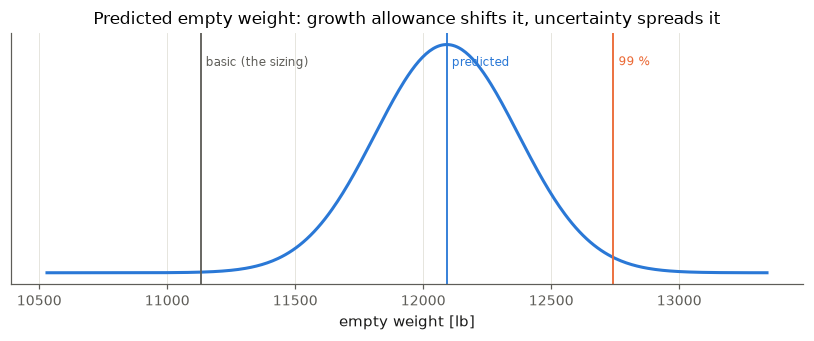

PASS  predicted OEW is the documented 12,092 lb (+-2)


In [7]:
from examples.halo_oew_uncertainty import oew_distribution, oew_items, probability_at_most
items = oew_items(ref)
dist = oew_distribution(items)
print(f"basic OEW {dist.basic_lb:,.0f} lb + growth {dist.growth_lb:,.0f} lb ({dist.growth_lb / dist.basic_lb:.1%}) "
      f"= predicted {dist.mean_lb:,.0f} lb;  sigma {dist.sigma_lb:,.0f} lb;  99 % value {dist.value_99_lb:,.0f} lb")
target_lb = dist.basic_lb
print(f"chance of meeting a not-to-exceed target at today's basic OEW ({target_lb:,.0f} lb): "
      f"{probability_at_most(dist, target_lb):.1e}")
x = np.linspace(dist.basic_lb - 600, dist.value_99_lb + 600, 400)
density = np.exp(-0.5 * ((x - dist.mean_lb) / dist.sigma_lb)**2)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(x, density, color=blue, lw=2)
for value, label, color in ((dist.basic_lb, "basic (the sizing)", ink_muted), (dist.mean_lb, "predicted", blue),
                            (dist.value_99_lb, "99 %", orange)):
    ax.axvline(value, color=color, lw=1.2); ax.text(value + 20, 0.95, label, color=color, fontsize=8, va="top")
ax.set(xlabel="empty weight [lb]", yticks=[], title="Predicted empty weight: growth allowance shifts it, uncertainty spreads it")
plt.tight_layout(); plt.show()
check("predicted OEW is the documented 12,092 lb (+-2)", abs(dist.mean_lb - 12092) < 2)

The growth allowance (about 960 lb) is more than three standard deviations (280 lb): sizing to the basic weight
means essentially no chance of meeting a not-to-exceed target set at that weight; the 99 % value is about 1,600 lb
over. And σ is likely optimistic: the items are not independent (every Raymer group calibrated on the same aircraft
can be biased the same way), and the spread is at fixed take-off weight, without the growth factor of about 3.

## Why it is built this way

- **Handbook plus calibration** is the standard conceptual-design practice, and the only one that is honest about
  where numbers come from at this stage: each group has a named equation, a named source, and a visible factor.
- **A stiffness-sized wing model** because tiltrotor wings are sized by whirl-flutter frequency placement, which a GA
  strength regression cannot see (it under-predicted the XV-15 wing by half).
- **A design rotor speed as a variable** with per-point margins turns whirl flutter into smooth constraints: no hidden
  iteration, no eigenvalue solve in the loop.
- **Closure as an equality** (tutorial 01): exact derivatives of every correlation, and the multiplier gives the
  growth factor for free.
- **Growth and uncertainty kept separate**, because they answer different questions (what will it weigh when mature?
  how sure are we?).

## What it can't do

- **Wing strength at ultimate load is not demonstrated.** A linear CalculiX check (plan 031/038) puts the peak
  spar-cap strain 10 % above the ultimate allowable in the jump take-off, with the raw AFDD gauges and an idealized
  root clamp (whether the 1.33 calibration material is load-carrying is open). No buckling analysis yet; plate
  estimates suggest the 1 mm covers need stiffening.
- **Whirl flutter is a frequency margin, not a stability analysis**: no rotor-pylon-wing eigenvalues, no damping.
- **Weights calibrate on one aircraft**, with some factors (flight controls ≈ 4, rotor via ν) that are really
  stand-ins for missing physics.
- **Structural loads use cruise dynamic pressure, not a dive speed**: Raymer fuselage mass ∝ q^0.241, so a faster
  cruise makes the fuselage heavier. The design log's cost optimum ran to 210 kt partly against this lever.
- **No weight margin in the sizing**: the baseline is sized to the basic estimate.

## What's next

- **Weights work package** (README): run weight control from the item table, allocate a not-to-exceed weight per
  item, and **carry each item's growth allowance and uncertainty inside the sizing** so the aircraft is sized to its
  99 % value.
- **Stress and aeroelasticity work package:** start from the exported Nastran decks; real fittings and stiffened
  covers; strength and buckling (SOL 101, 105) to a margin ≥ 0 at ultimate; return calibrated wing weights to the
  sizing. Then Nastran flutter (SOL 145) and whirl flutter with rotor aerodynamics, replacing the frequency margins.
- A coupled rotor-pylon-wing whirl model in CasADi (`NEXT_STEPS.md` §1): a small eigenproblem with the critical
  eigenpair as variables and a damping margin at 1.2 V_D.

## Check yourself

<details><summary>1. Why does the XV-15 calibration not validate the weights model?</summary>

Each factor is defined as actual / predicted on the XV-15, so the calibrated model reproduces the XV-15 by
construction. Validation requires predicting something not used in the fit: the D266 and V-22 wings, the JVX rotor,
the hot-day hover weights.
</details>

<details><summary>2. Why is the tiltrotor wing sized by frequencies rather than strength?</summary>

Heavy rotors and nacelles at the tips make the wing's torsion and beam modes the critical design condition: they
must stay above the rotor's once-per-rev in airplane mode to avoid whirl flutter. Stiffness for that costs more
structure than strength does; strength is then checked in a 2 g jump take-off.
</details>

<details><summary>3. What does the Lagrange multiplier on the closure constraint tell you?</summary>

How much the optimal take-off mass changes per unit of fixed mass added: the weight growth factor (1.17 on the
fixed-geometry XV-15; about 3 on the fully resized Halo).
</details>

<details><summary>4. The baseline OEW is 11,130 lb. What should you tell a program manager?</summary>

That is the basic estimate. With maturity-based growth allowances the prediction is about 12,090 lb, with a 1σ of
about 280 lb (likely optimistic), so the 99 % value is about 12,740 lb, and every pound of growth costs about three
at take-off. A target at the basic weight would almost certainly be missed.
</details>

In [8]:
check_summary()

6 of 6 checks passed
